In [3]:
import pandas as pd
import numpy as np
import os

from tools.text_tools import tokenization_and_remove_stopwords
from tools.visualization_tools import draw_word_cloud
from tools.semantic_network_tools import plot_co_occr_network

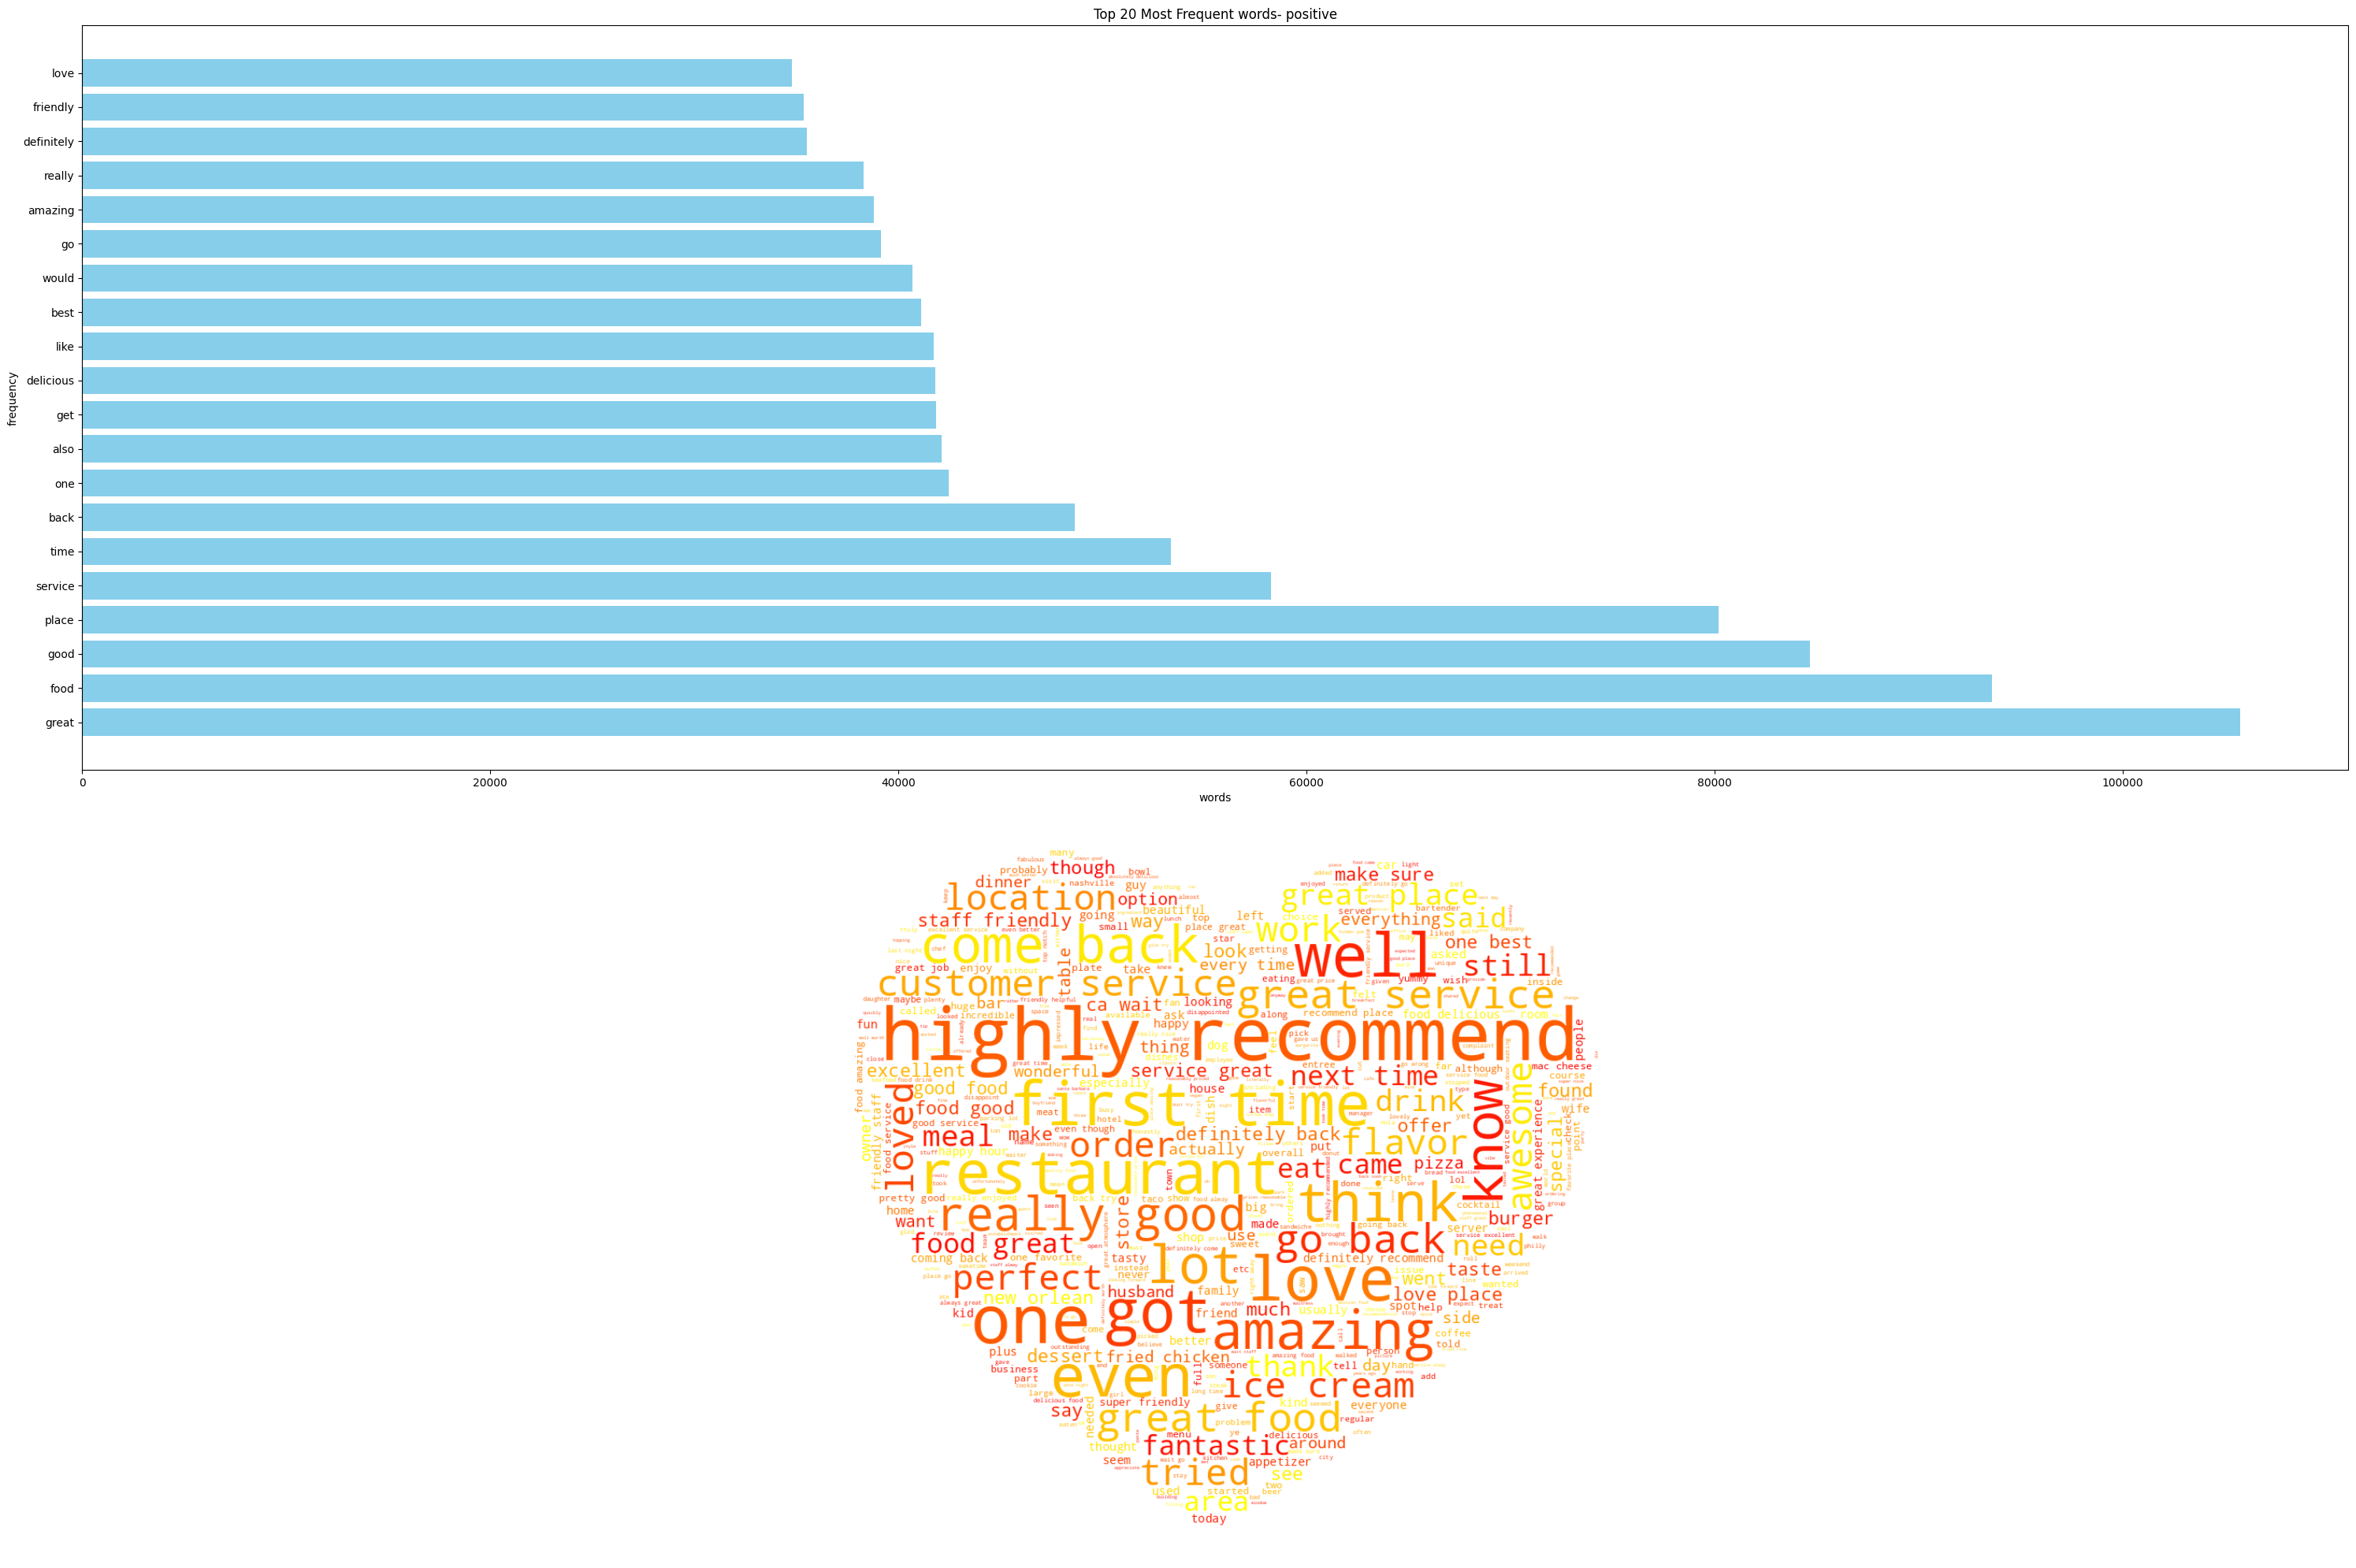

generate cooccurrence matrix: 100%|██████████| 199770/199770 [03:33<00:00, 937.84it/s] 


symmetrize ended!
start to plot!


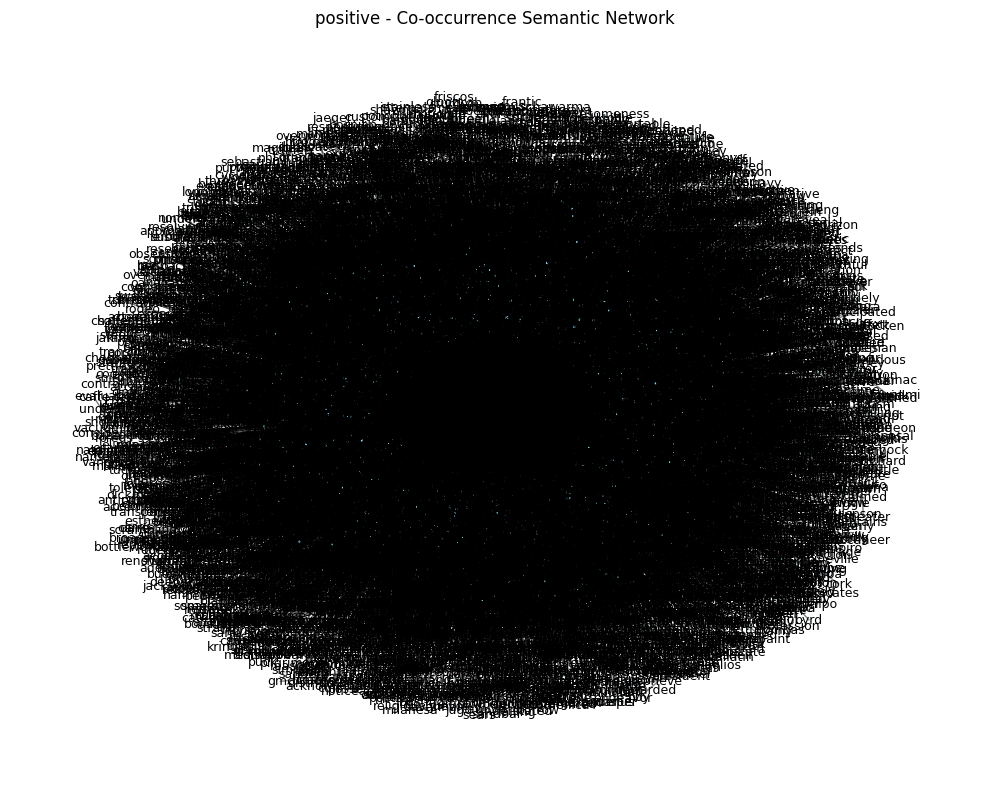

plot ended!


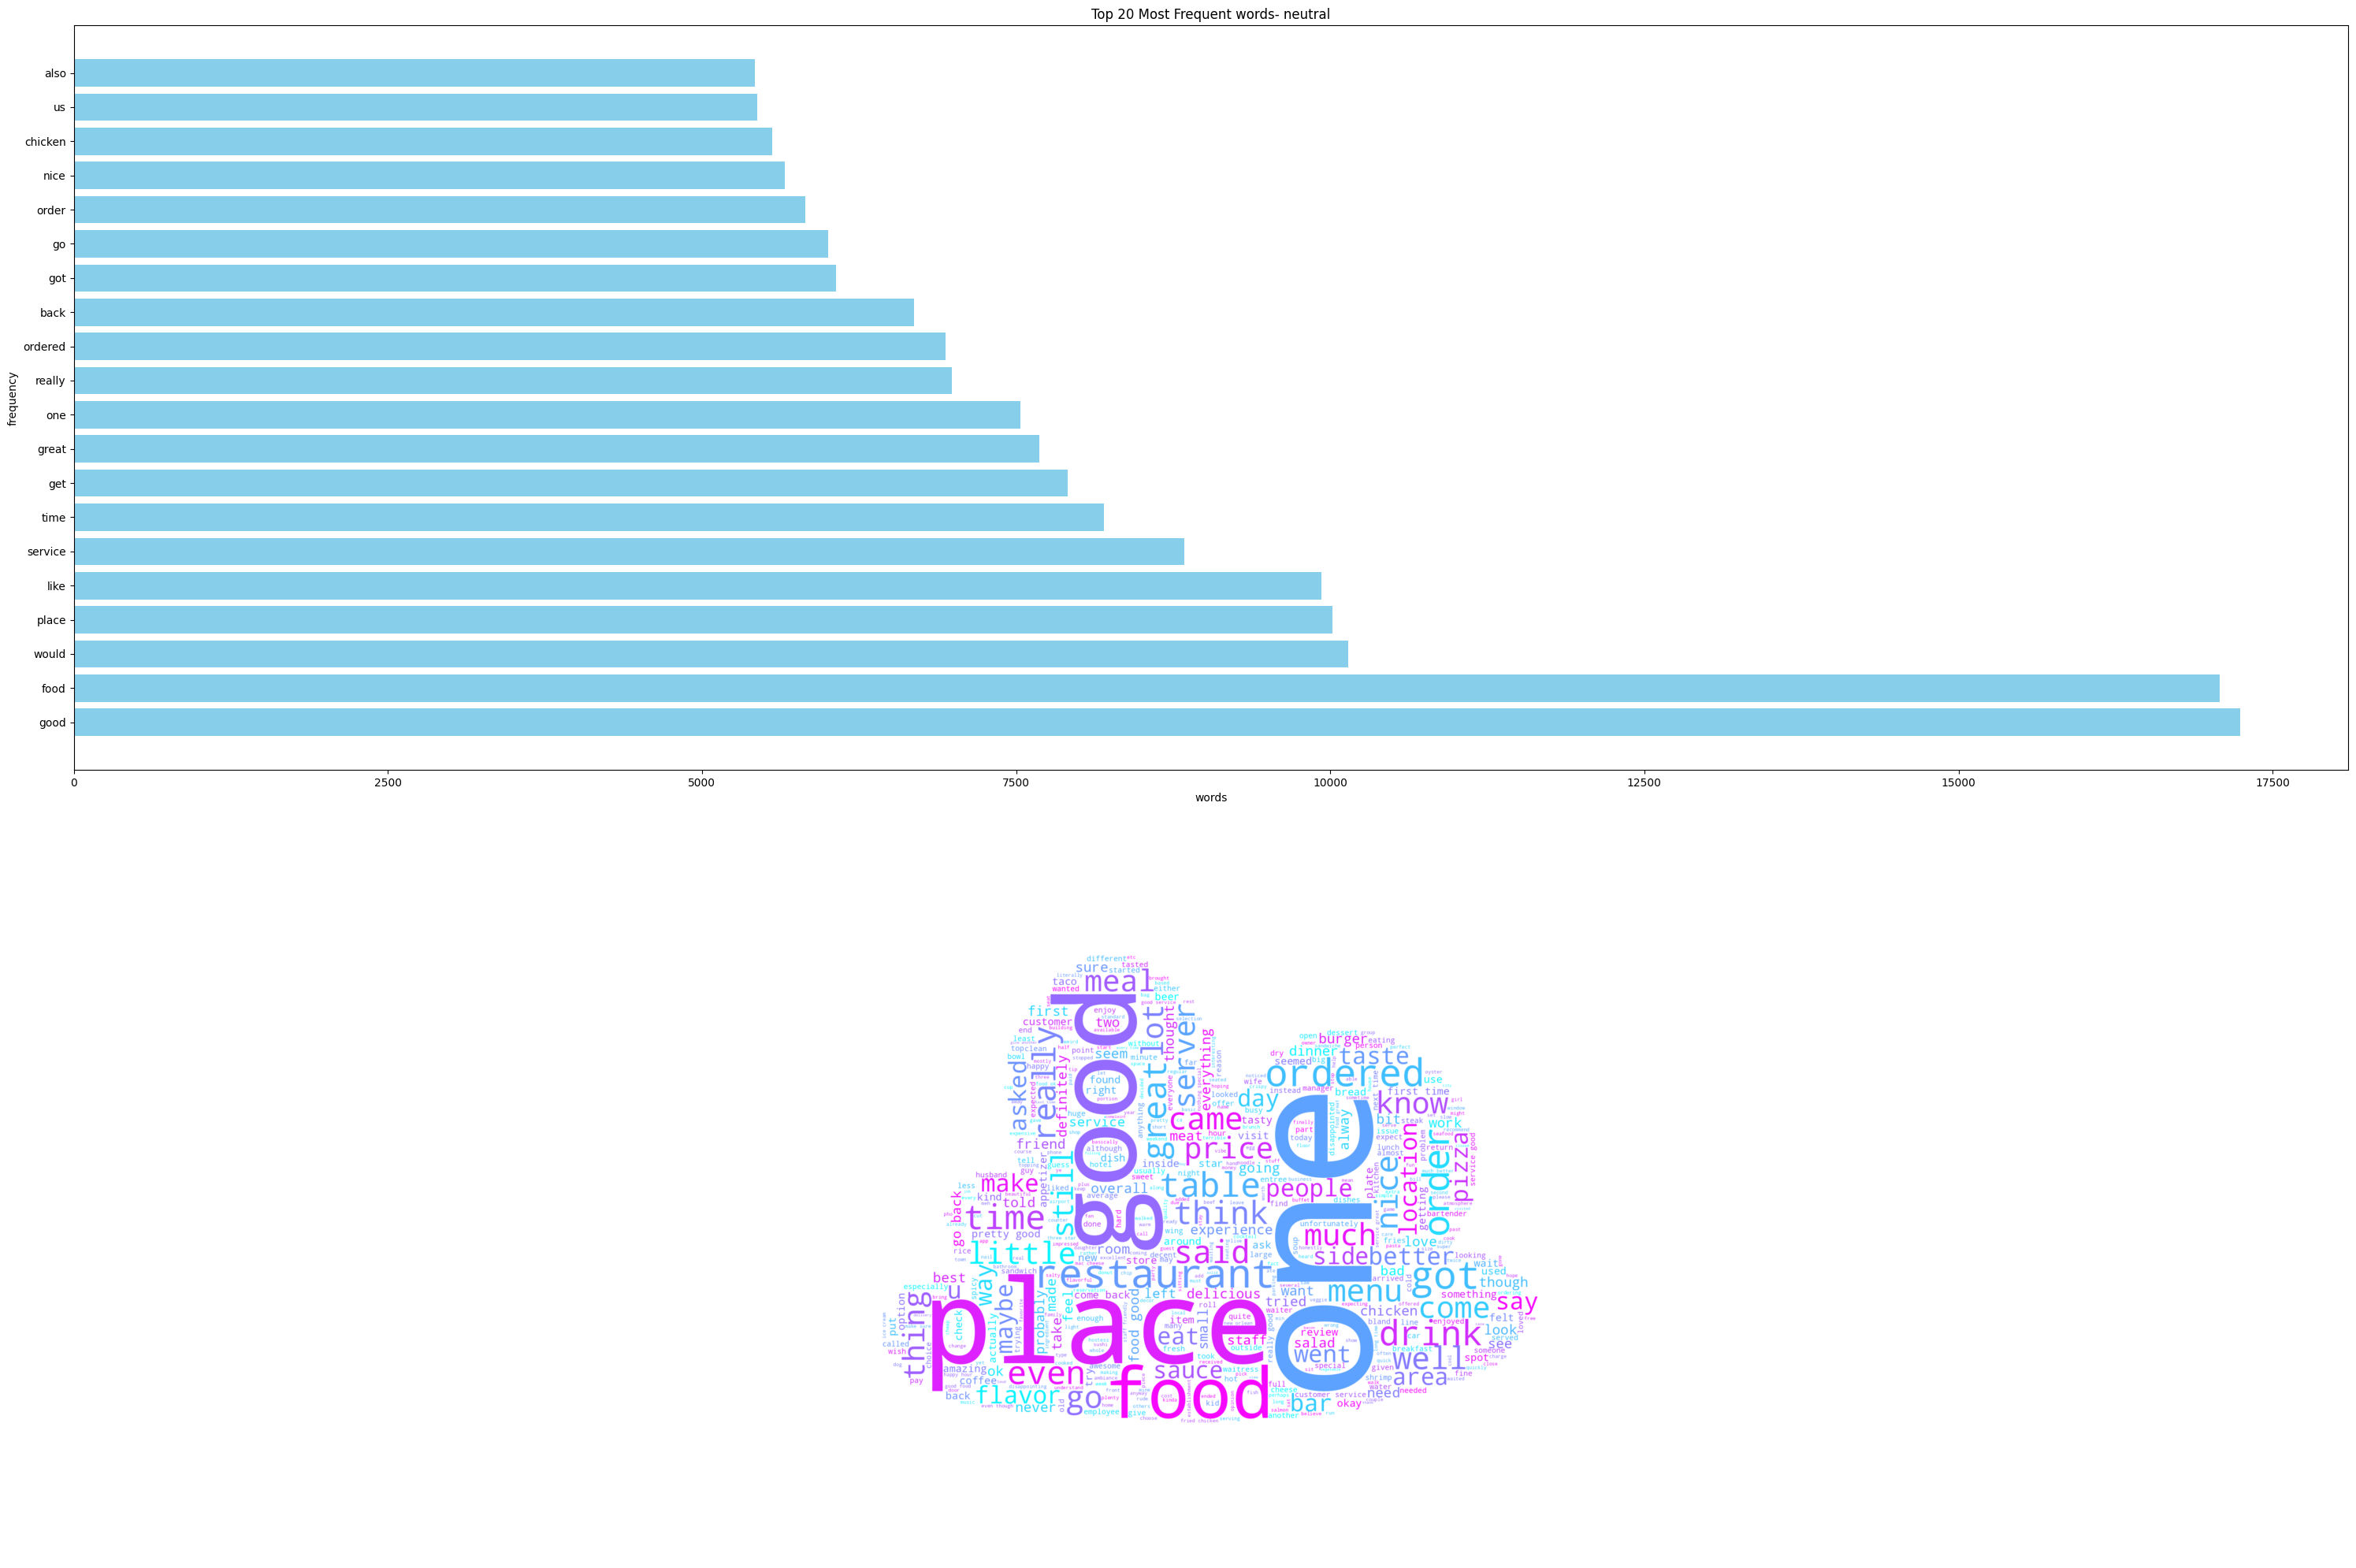

generate cooccurrence matrix: 100%|██████████| 23421/23421 [00:35<00:00, 652.88it/s]


symmetrize ended!
start to plot!


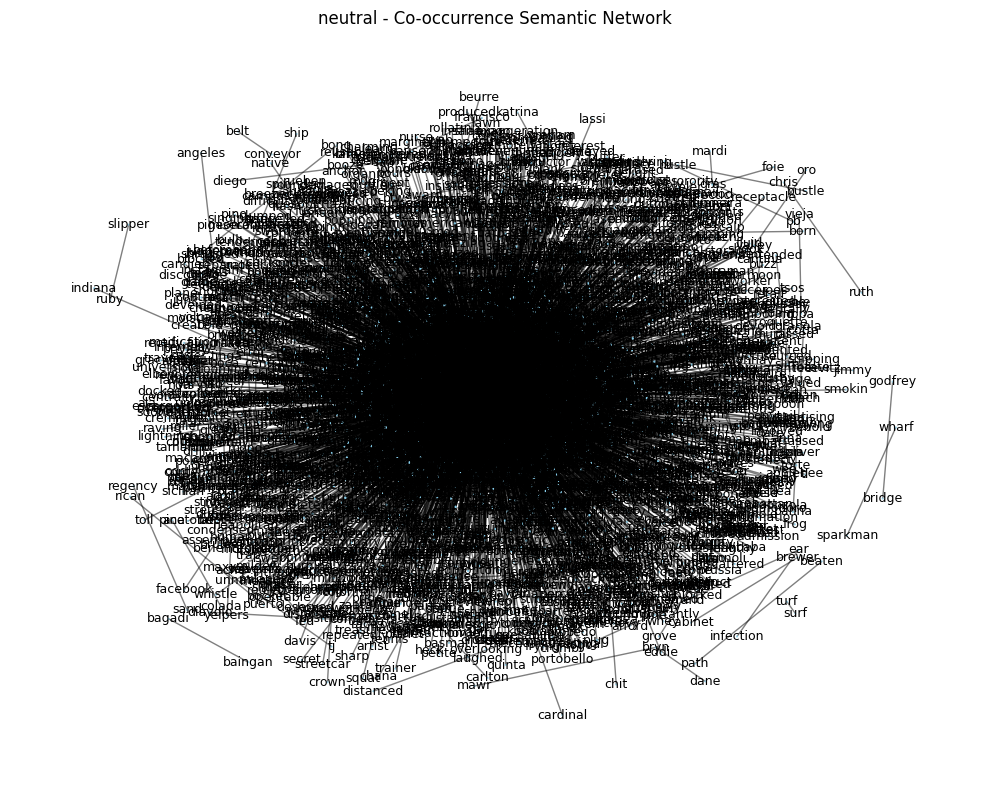

plot ended!


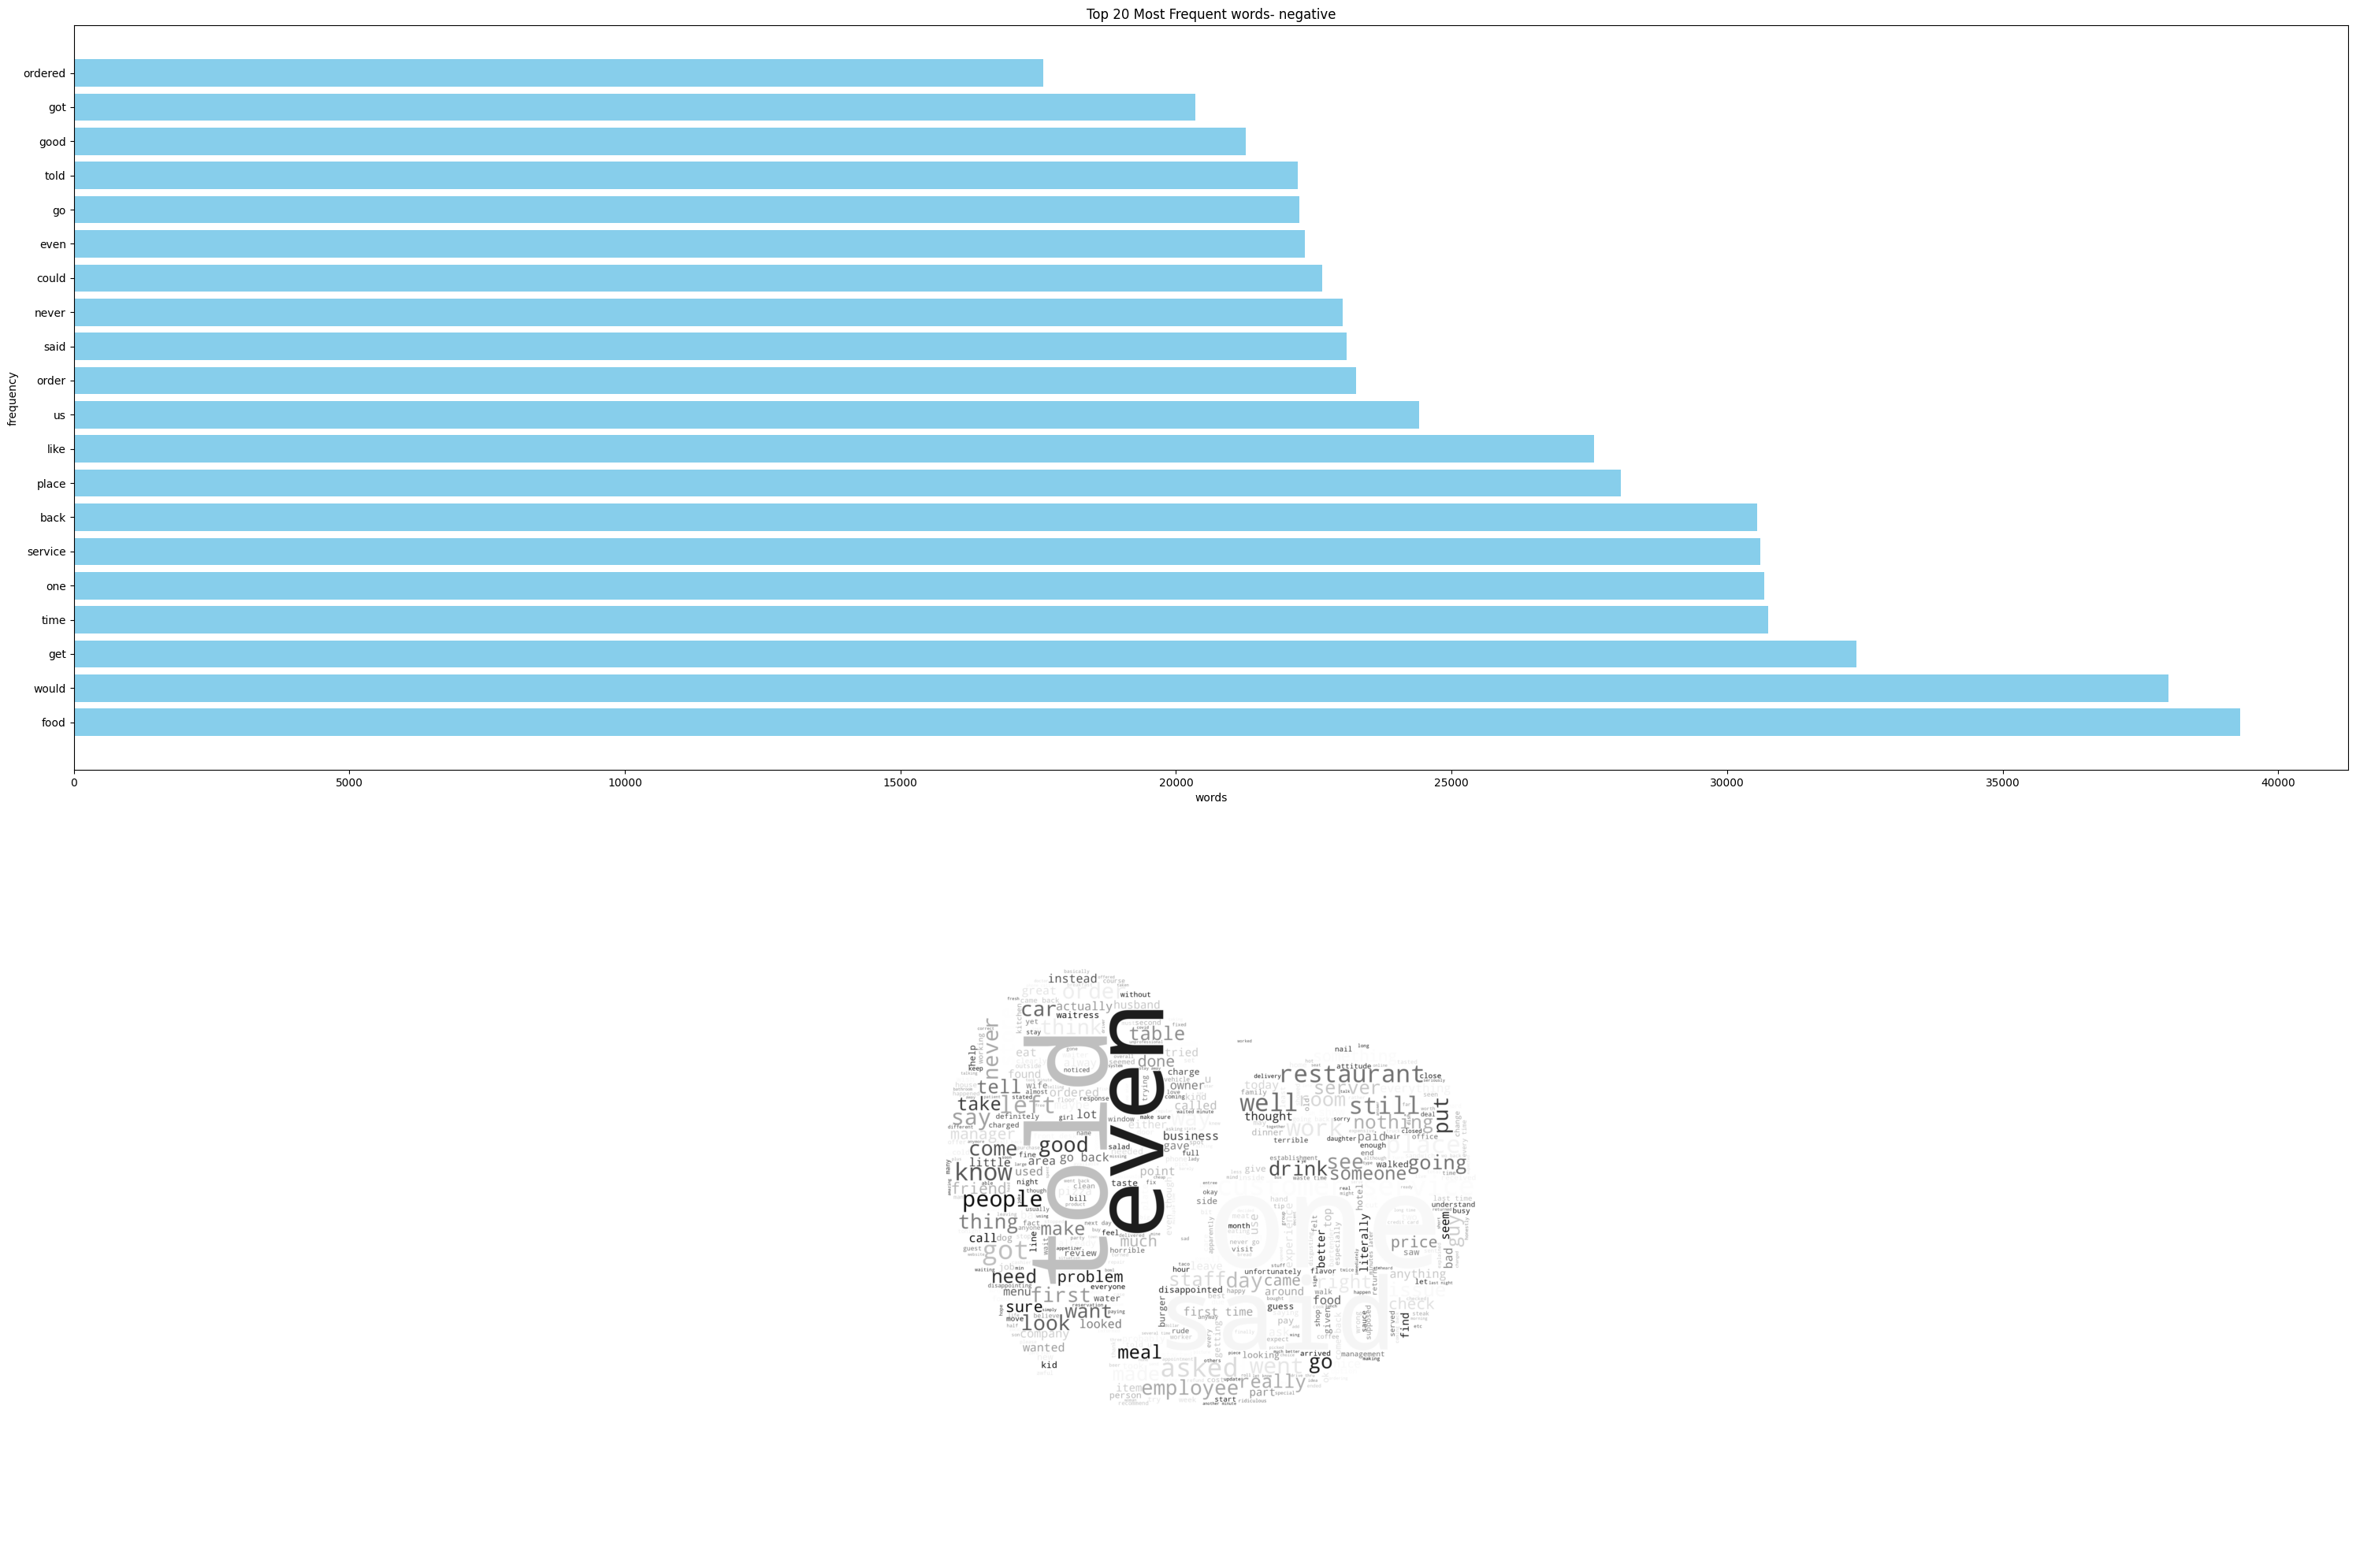

generate cooccurrence matrix: 100%|██████████| 74992/74992 [02:01<00:00, 616.20it/s]


symmetrize ended!
start to plot!


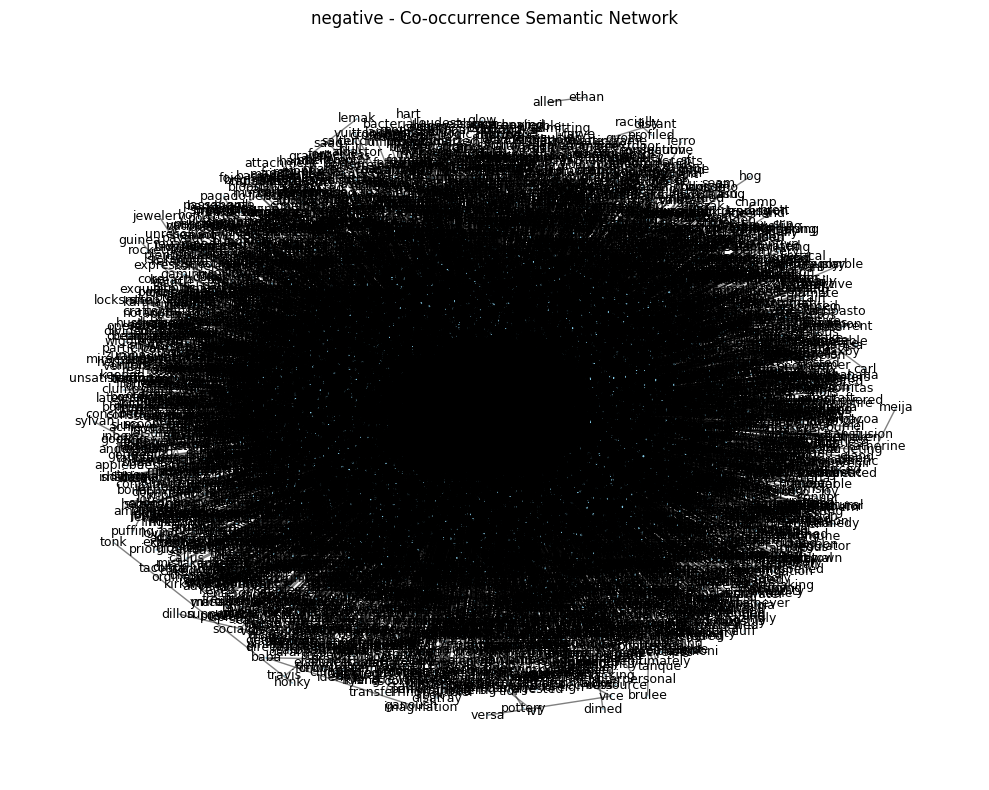

plot ended!


In [4]:
filepath = '../text_analysis/data/yelp_academic_dataset_review.xlsx'
keyVars = ['stars', 'text']
labels = ['positive', 'neutral', 'negative']
img_names = ['heart.jpg', 'cloud.jpg', 'broken_heart.jpg']
colormaps = ['autumn', 'cool', 'Greys']

df = pd.read_excel(filepath)
df = df[keyVars]
df.dropna(subset=['text'], inplace=True)

df['labels'] = " "
df.loc[(df['stars'] == 4) | (df['stars'] == 5), 'labels'] = 'positive'
df.loc[(df['stars'] == 3), 'labels'] = 'neutral'
df.loc[(df['stars'] == 2) | (df['stars'] == 1), 'labels'] = 'negative'

for i, label, img_name in zip(range(len(labels)), labels, img_names):
    img_path = os.path.join('../text_analysis/figs', img_name)
    review_list = list(df.loc[df['labels'] == label, 'text'])
    review_list = [tokenization_and_remove_stopwords(review) for review in review_list]
    draw_word_cloud(
        review_list=review_list,
        label=label,
        max_words=500,
        k=20,
        mask_path=img_path,
        colormap=colormaps[i]
    )
    plot_co_occr_network(review_list=review_list,
                         window_size=10,
                         min_freq=50,
                         label=label
    )
